#Step 1 – Choose a Data Source

Disease Risk Prediction Dataset – Kaggle

#Step 2 – Describe Your Dataset

Create a short document answering the following:
1. What is your data source?

    Our data source is the Disease Risk Prediction Dataset available on Kaggle.

2. Why did you choose it?

    We chose this dataset because it is healthcare-related, easy to understand, and useful for data cleaning and analysis.

3. What information does it contain?

    It contains health-related information about individuals that can be used to analyze and predict disease risk.

4. Is it structured, semi-structured, or unstructured?

    It is structured data because it is organized into rows and columns.

5. What format is the data?

    The dataset is available in CSV format.

6. How frequently is the data updated?

    It is a downloadable Kaggle dataset and does not have a fixed automatic update frequency, updates depend on the dataset creator.

##Step 3 – Design Your ETL Pipeline

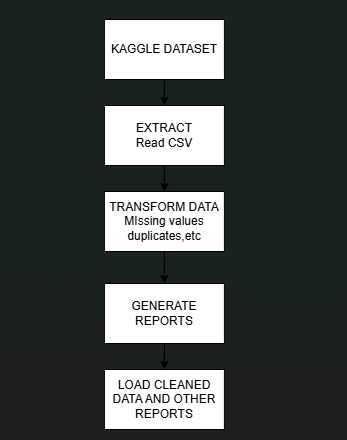

##Step 4 – Create the Project Structure



folders created

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

##Step 5 – Build the Extract Function

In [ ]:
# EXTRACT
def extract():
  raw_data=pd.read_csv('/content/disease_prediction/raw_data/synthetic_disease_risk_dataset.csv')
  print(raw_data.shape)
  return raw_data

##Step 6 – Build the Transform Function

In [ ]:
# TRANSFORM
def transform(data):

  #check duplicates
  print(data.duplicated().sum())
  # no duplicates

  # Missing values
  print(data.isna().sum())    # here 2 columns have missing values
  # in alcohol consumption none values represent no consumption
  # in previous diagnosis none values represent no previous diagnosis
  data["Alcohol_Consumption"] = data["Alcohol_Consumption"].fillna("no ")
  data["Previous_Diagnosis"] = data["Previous_Diagnosis"].fillna("not diagnosed")
  print(data.isna().sum())
  # check datatype mismatch
  print(data.info())  # no mismatch
  # sorting in order of age
  data = data.sort_values(by="Age", ascending=True)
  print(data.describe())
  print(data.head())
  return data

##Step 8 – Load

In [ ]:
def load(clean_data,summary,risk_report):
  file_path='/content/disease_prediction/reports/cleaned_data.csv'
  if not os.path.exists(file_path):
    clean_data.to_csv(file_path,mode='w',header=True,index=False)
  else:
    clean_data.to_csv(file_path,mode='a',header=True,index=False)
  print('cleaned_Data stored successfully')
  risk_report.to_csv("/content/disease_prediction/reports/Risk_report.csv", index=False)
  print('risk_report stored successfully')
  summary.to_csv("/content/disease_prediction/reports/summary_data.csv")
  print('summary_data stored successfully')


In [ ]:
def run_pipeline():
  data=extract()
  clean_data=transform(data)
  summary = data.describe()
  risk_report = data["Disease_Risk"].value_counts().reset_index()
  risk_report.columns = ["Disease_Risk", "Patient_Count"]
  load(clean_data,summary,risk_report)

##Step 9 – Build the Pipeline

In [ ]:
run_pipeline()    #pipeline created

(4000, 15)
0
Patient_ID                     0
Age                            0
Gender                         0
BMI                            0
Smoking_Status                 0
Alcohol_Consumption         1639
Physical_Activity_Level        0
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Cholesterol_Level              0
Glucose_Level                  0
Family_History                 0
Genetic_Risk_Score             0
Previous_Diagnosis          2027
Disease_Risk                   0
dtype: int64
Patient_ID                  0
Age                         0
Gender                      0
BMI                         0
Smoking_Status              0
Alcohol_Consumption         0
Physical_Activity_Level     0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Cholesterol_Level           0
Glucose_Level               0
Family_History              0
Genetic_Risk_Score          0
Previous_Diagnosis          0
Disease_Risk                0
dtype: int64
<class 'pandas.c

In [ ]:
df=pd.read_csv('/content/disease_prediction/reports/cleaned_data.csv')

In [ ]:
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Glucose_Level,Family_History,Genetic_Risk_Score,Previous_Diagnosis,Disease_Risk
0,P100543,18,Male,28.8,Former,Moderate,High,155,64,197,153,No,0.44,not diagnosed,No
1,P103697,18,Male,27.1,Never,Moderate,Moderate,122,111,283,104,Yes,0.31,Pre-disease,No
2,P100590,18,Female,31.7,Never,no,Moderate,91,98,248,163,No,0.42,Pre-disease,No
3,P100602,18,Male,28.6,Never,Moderate,Low,178,85,238,74,No,0.61,not diagnosed,No
4,P102802,18,Female,28.2,Former,no,Moderate,114,66,200,166,Yes,0.56,not diagnosed,No


In [ ]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Physical_Activity_Level,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Level,0


In [ ]:
df =df.drop('Patient_ID',axis = 1)

## Outlier handling

In [ ]:
numeric_cols = [
    'Age', 'BMI', 'Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic', 'Cholesterol_Level',
    'Glucose_Level', 'Genetic_Risk_Score'
]

# 1. Convert to numbers (errors='coerce' will turn any remaining text headers into NaN)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Drop the rows that had the header text artifacts (which are now NaN)
df = df.dropna(subset=numeric_cols)

# 3. Convert fields that should be whole integers (like Age and Blood Pressure)
int_cols = ['Age', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic']
df[int_cols] = df[int_cols].astype(int)

# Verify the final data types
print(df.dtypes)

Age                           int64
Gender                       object
BMI                         float64
Smoking_Status               object
Alcohol_Consumption          object
Physical_Activity_Level      object
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Cholesterol_Level           float64
Glucose_Level               float64
Family_History               object
Genetic_Risk_Score          float64
Previous_Diagnosis           object
Disease_Risk                 object
dtype: object


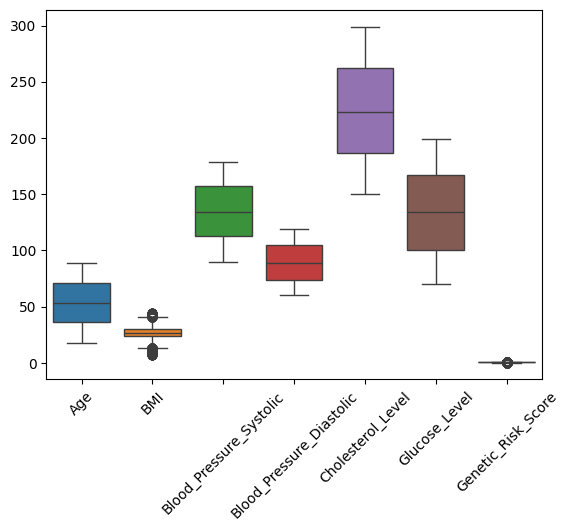

In [ ]:
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

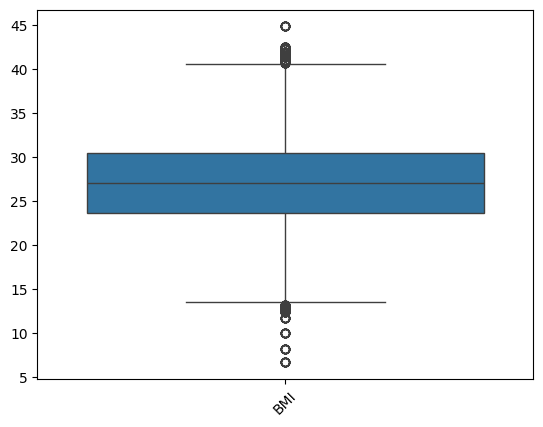

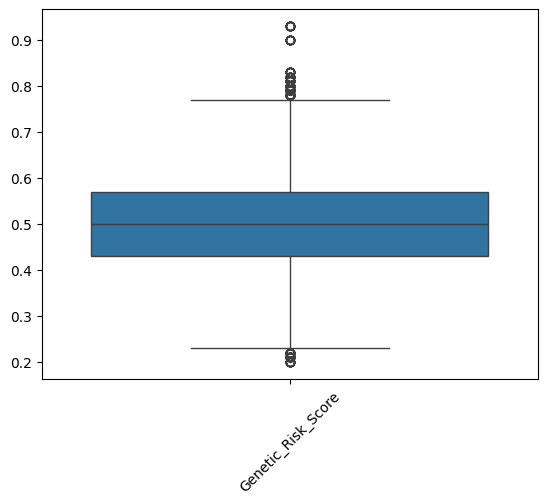

In [ ]:
sns.boxplot(df[['BMI']])
plt.xticks(rotation=45)
plt.show()
sns.boxplot(df[['Genetic_Risk_Score']])
plt.xticks(rotation=45)
plt.show()

## Encoding

Label encoding family_history, Gender and Disease_risk

In [ ]:
df = df[
    (df['Gender'] != 'Gender') &
    (df['Family_History'] != 'Family_History') &
    (df['Disease_Risk'] != 'Disease_Risk')
]

In [ ]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender','Family_History','Disease_Risk']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Glucose_Level,Family_History,Genetic_Risk_Score,Previous_Diagnosis,Disease_Risk
0,18,1,28.8,Former,Moderate,High,155,64,197.0,153.0,0,0.44,not diagnosed,0
1,18,1,27.1,Never,Moderate,Moderate,122,111,283.0,104.0,1,0.31,Pre-disease,0
2,18,0,31.7,Never,no,Moderate,91,98,248.0,163.0,0,0.42,Pre-disease,0
3,18,1,28.6,Never,Moderate,Low,178,85,238.0,74.0,0,0.61,not diagnosed,0
4,18,0,28.2,Former,no,Moderate,114,66,200.0,166.0,1,0.56,not diagnosed,0


In [ ]:
df = df[
    (df['Smoking_Status'] != 'Smoking_Status') &
    (df['Alcohol_Consumption'] != 'Alcohol_Consumption') &
    (df['Physical_Activity_Level'] != 'Physical_Activity_Level') &
    (df['Previous_Diagnosis'] != 'Previous_Diagnosis')
]


In [ ]:
smoking_map = {'Never': 0, 'Former': 1, 'Current': 2}
df['Smoking_Status'] = df['Smoking_Status'].map(smoking_map).astype(int)

In [ ]:
alcohol_map = {'no ': 0, 'Moderate': 1, 'High': 2}
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].map(alcohol_map).astype(int)

In [ ]:
activity_map = {'High': 0, 'Moderate': 1, 'Low': 2}
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].map(activity_map).astype(int)

In [ ]:
diagnosis_map = {'not diagnosed': 0, 'Pre-disease': 1, 'Diagnosed': 2}
df['Previous_Diagnosis'] = df['Previous_Diagnosis'].map(diagnosis_map).astype(int)

In [ ]:
print(df[['Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Previous_Diagnosis']].dtypes)


Smoking_Status             int64
Alcohol_Consumption        int64
Physical_Activity_Level    int64
Previous_Diagnosis         int64
dtype: object


In [ ]:
df.head()

,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Glucose_Level,Family_History,Genetic_Risk_Score,Previous_Diagnosis,Disease_Risk
0,18,1,28.8,1,1,0,155,64,197.0,153.0,0,0.44,0,0
1,18,1,27.1,0,1,1,122,111,283.0,104.0,1,0.31,1,0
2,18,0,31.7,0,0,1,91,98,248.0,163.0,0,0.42,1,0
3,18,1,28.6,0,1,2,178,85,238.0,74.0,0,0.61,0,0
4,18,0,28.2,1,0,1,114,66,200.0,166.0,1,0.56,0,0


##Scaling

In [ ]:
x=df.drop('Disease_Risk', axis =1)
y=df['Disease_Risk']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Split into Train and Test data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

cols_to_scale = [
    'Age', 'Gender', 'Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic', 'Cholesterol_Level',
    'Glucose_Level', 'Genetic_Risk_Score'
]
ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scale)
    ],remainder='passthrough'
)
X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)

In [ ]:
X_train_scaled

array([[ 0.18298537, -0.99070312, -0.21703899, ...,  2.        ,
         0.        ,  1.        ],
       [ 1.58945755, -0.99070312, -1.52905969, ...,  1.        ,
         1.        ,  0.        ],
       [-0.49600121, -0.99070312, -1.02740472, ...,  1.        ,
         1.        ,  2.        ],
       ...,
       [ 1.73495468,  0.77826857, -0.40998321, ...,  0.        ,
         1.        ,  2.        ],
       [ 1.58945755,  0.77826857, -0.06268362, ...,  1.        ,
         0.        ,  2.        ],
       [ 1.68645564,  0.77826857, -1.41329316, ...,  1.        ,
         1.        ,  0.        ]])

In [ ]:
X_test_scaled

array([[ 0.8134729 ,  0.77826857, -0.10127246, ...,  2.        ,
         1.        ,  1.        ],
       [ 1.20146523,  0.77826857, -0.40998321, ...,  2.        ,
         1.        ,  0.        ],
       [-1.3204849 ,  0.77826857, -0.29421668, ...,  1.        ,
         1.        ,  1.        ],
       ...,
       [-0.78699545, -0.99070312,  1.40369246, ...,  2.        ,
         1.        ,  2.        ],
       [-0.20500696,  0.77826857,  1.44228131, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.20146523, -0.99070312, -1.22034894, ...,  1.        ,
         0.        ,  1.        ]])

##Before and After  Scaling

In [ ]:
#Before
X_train

,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Glucose_Level,Family_History,Genetic_Risk_Score,Previous_Diagnosis
10208,57,0,22.4,0,0,2,129,104,213.0,95.0,0,0.49,1
35853,86,0,22.7,2,0,1,95,101,180.0,174.0,1,0.54,0
41440,43,0,27.7,0,0,1,108,110,277.0,122.0,1,0.49,2
1944,52,0,24.1,1,1,0,94,77,223.0,162.0,1,0.47,1
44221,21,1,29.1,0,0,2,126,118,263.0,102.0,1,0.48,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17096,37,0,23.5,0,1,2,164,108,170.0,105.0,1,0.55,1
48521,27,0,30.5,1,1,2,145,100,160.0,92.0,1,0.56,0
11970,89,1,24.2,1,2,0,124,82,189.0,139.0,1,0.37,2
55869,86,1,19.4,0,0,1,133,77,298.0,72.0,0,0.56,2


In [ ]:
##After
X_train_scaled

array([[ 0.18298537, -0.99070312, -0.21703899, ...,  2.        ,
         0.        ,  1.        ],
       [ 1.58945755, -0.99070312, -1.52905969, ...,  1.        ,
         1.        ,  0.        ],
       [-0.49600121, -0.99070312, -1.02740472, ...,  1.        ,
         1.        ,  2.        ],
       ...,
       [ 1.73495468,  0.77826857, -0.40998321, ...,  0.        ,
         1.        ,  2.        ],
       [ 1.58945755,  0.77826857, -0.06268362, ...,  1.        ,
         0.        ,  2.        ],
       [ 1.68645564,  0.77826857, -1.41329316, ...,  1.        ,
         1.        ,  0.        ]])